In [6]:
import os, torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
import pandas as pd, numpy as np
import time, glob, warnings
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_curve, roc_auc_score,
                             average_precision_score)
from tabulate import tabulate
from IPython.display import clear_output
import torchaudio, torchaudio.transforms as T
import scipy.signal as signal
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import timm
import seaborn as sns

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

SR = 16000
CHUNK_SEC = 30
CHUNK_LEN = CHUNK_SEC * SR

label_map = {'Active': 0, 'Queenless': 1, 'Infested': 2}
inv_label_map = {v:k for k,v in label_map.items()}
class_names = ['Active', 'Queenless', 'Infested']
N_CLASSES = 3
USE_SYNTHETIC = True
FILTER_LOW_RMS = True

csv_frdr = r"dataset\\urban-frdr\\inspections_2022.csv"
csv_zenodo = r"dataset\\zenodo\\state_labels.csv"
frdr_audio = r"dataset/urban-frdr/audio_2022_all_chunk"
zenodo_audio = r"dataset\\zenodo"
os.makedirs('models', exist_ok=True)
os.makedirs('synthetic_cache', exist_ok=True)

Device: cuda


## 1. Load and Prepare Metadata

### Formatting FRDR Data

In [7]:
df_frdr = pd.read_csv(csv_frdr)

all_files = os.listdir(frdr_audio)
extract_list = []
for f in all_files:
    if not f.endswith('.wav'): continue
    parts = f.split('_')
    date = pd.to_datetime(parts[0], format='%d-%m-%Y').strftime('%Y-%m-%d')
    hive_id = parts[2].split('-')[1].split('.')[0]
    extract_list.append({'Filename': f, 'Date': date, 'Tag number': int(hive_id)})

df_audio = pd.DataFrame(extract_list)
df_audio['Tag number'] = df_audio['Tag number'].astype(int)
df_frdr['Tag number'] = df_frdr['Tag number'].astype(int)
df_frdr['Date'] = pd.to_datetime(df_frdr['Date']).dt.strftime('%Y-%m-%d')
df_frdr_sorted = df_frdr.sort_values(by=['Date', 'Tag number', 'Category'],
                                      ascending=[True, True, False])
df_frdr_clean = df_frdr_sorted.drop_duplicates(subset=['Date', 'Tag number'], keep='first')
merge_df = pd.merge(df_audio, df_frdr_clean, on=['Date', 'Tag number'], how='inner')

def check_class(row):
    if row['Category'] == 'varroa': return 'Infested'
    elif row['Queen status'] == 'queenless': return 'Queenless'
    elif row['Queen status'] == 'queenright' and row['Is alive'] == 1: return 'Active'
    else: return 'Others / Ignored'

merge_df['Class'] = merge_df.apply(check_class, axis=1)
merge_df = merge_df[merge_df['Class'] != 'Others / Ignored']
print('FRDR class counts (inspections match):')
print(merge_df['Class'].value_counts())

FRDR class counts (inspections match):
Class
Infested     162
Active       147
Queenless     83
Name: count, dtype: int64


### Formatting Data Zenodo Data

In [8]:
frdr_files = glob.glob(os.path.join(frdr_audio, "*.wav"))
frdr_data = []
for path in frdr_files:
    fn = os.path.basename(path)
    if any(s in fn for s in ["_Active", "_Queenless", "_Infested"]):
        name_part = os.path.splitext(fn)[0]
        parts = name_part.split('_')
        class_label = parts[-1]
        hive_id = "Unknown"
        for p in parts:
            if "HIVE" in p: hive_id = p; break
        frdr_data.append({'File_Path': path, 'Filename': fn, 'Dataset': 'FRDR',
                          'Class': class_label, 'Hive': hive_id})
df_frdr_all = pd.DataFrame(frdr_data)

zenodo_files = glob.glob(os.path.join(zenodo_audio, "*", "*.wav"))
zenodo_data = []
for path in zenodo_files:
    fn = os.path.basename(path)
    folder = os.path.basename(os.path.dirname(path))
    if "NO_QueenBee" in fn: cls = "Queenless"
    elif "QueenBee" in fn: cls = "Active"
    else: continue
    hive = folder.split('_')[0]
    zenodo_data.append({'File_Path': path, 'Filename': fn, 'Dataset': 'ZENODO',
                        'Class': cls, 'Hive': hive})
df_zenodo_all = pd.DataFrame(zenodo_data)

print(f"FRDR: {len(df_frdr_all)} | Zenodo: {len(df_zenodo_all)}")
print('FRDR class distribution:')
print(df_frdr_all['Class'].value_counts())
print('Zenodo class distribution:')
print(df_zenodo_all['Class'].value_counts())

FRDR: 393 | Zenodo: 576
FRDR class distribution:
Class
Infested     163
Active       147
Queenless     83
Name: count, dtype: int64
Zenodo class distribution:
Class
Active       288
Queenless    288
Name: count, dtype: int64


## Data split with stratified
- Zenodo -> Class (2 Hive)
- FRDR -> Class, Hive (9 Hive)

In [9]:
def split_stratified(df, strat_col, test_size=0.20, val_frac=0.5, seed=42):
    s = df[strat_col] if strat_col in df.columns and df[strat_col].value_counts().min() >= 2 else None
    train_df, temp_df = train_test_split(df, test_size=test_size, random_state=seed, stratify=s)
    s2 = temp_df[strat_col] if s is not None and temp_df[strat_col].value_counts().min() >= 2 else None
    val_df, test_df = train_test_split(temp_df, test_size=val_frac, random_state=seed, stratify=s2)
    return train_df, val_df, test_df

zt, zv, zte = [], [], []
for _, g in df_zenodo_all.groupby('Dataset'):
    a,b,c = split_stratified(g, 'Class')
    zt.append(a); zv.append(b); zte.append(c)
train_zen = pd.concat(zt) if zt else pd.DataFrame()
val_zen = pd.concat(zv) if zv else pd.DataFrame()
test_zen = pd.concat(zte) if zte else pd.DataFrame()

df_frdr_all['SplitKey'] = df_frdr_all['Class'] + '_' + df_frdr_all['Hive']
cnts = df_frdr_all['SplitKey'].value_counts()
rare = cnts[cnts < 10].index
df_frdr_all['SplitKey'] = df_frdr_all['SplitKey'].apply(
    lambda x: x.split('_')[0] if x in rare else x)
train_fr, val_fr, test_fr = split_stratified(df_frdr_all, 'SplitKey')

train_df = pd.concat([train_zen, train_fr], ignore_index=True)
val_df = pd.concat([val_zen, val_fr], ignore_index=True)
test_df = pd.concat([test_zen, test_fr], ignore_index=True)
for d in [train_df, val_df, test_df]:
    d.drop(columns=['SplitKey'], errors='ignore', inplace=True)

print(f"Train = {len(train_df)} Val = {len(val_df)} Test = {len(test_df)}")
print('Train dist:', train_df['Class'].value_counts().to_dict())
print('Val dist:', val_df['Class'].value_counts().to_dict())
print('Test dist:', test_df['Class'].value_counts().to_dict())

Train = 774 Val = 97 Test = 98
Train dist: {'Active': 346, 'Queenless': 297, 'Infested': 131}
Val dist: {'Active': 45, 'Queenless': 36, 'Infested': 16}
Test dist: {'Active': 44, 'Queenless': 38, 'Infested': 16}


## 2. Mel-Spectrogram Transform (Improved params)

Better suited for bee audio: lower n_fft, finer freq resolution with more mels.

In [5]:
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_SIZE = 224

mel_transform = T.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT,
    hop_length=HOP_LENGTH, n_mels=N_MELS,
    f_min=0, f_max=8000
).to(DEVICE)

amp_to_db = T.AmplitudeToDB()

def make_mel(audio_chunk, target_size=(IMG_SIZE, IMG_SIZE)):
    if audio_chunk.dim() == 2 and audio_chunk.shape[0] > 1:
        audio_chunk = torch.mean(audio_chunk, dim=0, keepdim=True)
    if audio_chunk.dim() == 1:
        audio_chunk = audio_chunk.unsqueeze(0)
    mel = mel_transform(audio_chunk)
    mel_db = amp_to_db(mel)
    inp = mel_db.unsqueeze(0)
    resized = F.interpolate(inp, size=target_size, mode="bilinear",
                             align_corners=False).squeeze(0)
    mu = resized.mean()
    sg = resized.std().clamp(min=1e-6)
    mel_norm = (resized - mu) / sg
    mel_rgb = mel_norm.repeat(3, 1, 1)
    return mel_rgb


## 3. Synthetic Data Generation for Infested

Generate synthetic Infested audio clips via various waveform transformations.
This augments the minority class BEFORE chunking, so the model sees more varied Infested patterns.

In [ ]:
def add_noise(wave, noise_level=0.005):
    noise = torch.randn_like(wave) * noise_level * wave.std()
    return wave + noise

def pitch_shift(wave, sr, n_steps):
    ratio = 2.0 ** (n_steps / 12.0)
    new_len = int(wave.shape[-1] / ratio)
    resampled = F.interpolate(wave.unsqueeze(0), size=new_len,
                              mode="linear", align_corners=False).squeeze(0)
    if resampled.shape[-1] < wave.shape[-1]:
        pad = wave.shape[-1] - resampled.shape[-1]
        resampled = F.pad(resampled, (0, pad))
    else:
        resampled = resampled[:, :wave.shape[-1]]
    return resampled

def time_stretch(wave, rate):
    new_len = int(wave.shape[-1] / rate)
    stretched = F.interpolate(wave.unsqueeze(0), size=new_len,
                               mode="linear", align_corners=False).squeeze(0)
    if stretched.shape[-1] < wave.shape[-1]:
        pad = wave.shape[-1] - stretched.shape[-1]
        stretched = F.pad(stretched, (0, pad))
    else:
        stretched = stretched[:, :wave.shape[-1]]
    return stretched

In [ ]:
def generate_synthetic_chunks(df, class_label='Infested', n_synthetic_per_file=3,
                              chunk_len=CHUNK_LEN, sr=SR):
    target_df = df[df['Class'] == class_label].copy()
    syn_data = []
    sos_hp = signal.butter(5, 150, btype='highpass', fs=sr, output='sos')

    for _, row in tqdm(target_df.iterrows(), total=len(target_df),
                       desc=f'Generating synthetic {class_label}'):
        try:
            y_full, fs = torchaudio.load(row['File_Path'])
            if fs != sr:
                resampler = T.Resample(fs, sr).to(DEVICE)
                y_full = resampler(y_full.to(DEVICE))
            else:
                y_full = y_full.to(DEVICE)
            if y_full.shape[0] > 1:
                y_full = torch.mean(y_full, dim=0, keepdim=True)

            total_chunks = max(1, y_full.shape[1] // chunk_len)
            n_real_chunks = min(total_chunks, 2)

            for ci in range(n_real_chunks):
                y = y_full[:, ci*chunk_len:(ci+1)*chunk_len]
                if y.shape[1] < chunk_len:
                    y = F.pad(y, (0, chunk_len - y.shape[1]))

                for synth_i in range(n_synthetic_per_file):
                    y_aug = y.clone()
                    if np.random.rand() < 0.4:
                        n_steps = np.random.choice([-1, 1])
                        y_aug = pitch_shift(y_aug, sr, n_steps)
                    if np.random.rand() < 0.4:
                        rate = np.random.uniform(0.85, 1.15)
                        y_aug = time_stretch(y_aug, rate)
                    if np.random.rand() < 0.5:
                        level = np.random.uniform(0.001, 0.012)
                        y_aug = add_noise(y_aug, level)

                    # Voice Activity Detection

                    rms = torch.sqrt(torch.mean(y_aug**2))
                    if rms < 0.003: continue

                    y_np = y_aug.cpu().numpy()
                    y_filt = signal.sosfiltfilt(sos_hp, y_np).copy()
                    y_t = torch.from_numpy(y_filt).float().to(DEVICE)
                    mel_t = make_mel(y_t)

                    syn_data.append({
                        'File_Path': row['File_Path'],
                        'Filename': f"syn_{synth_i}_" + os.path.basename(row['File_Path']),
                        'Class': class_label,
                        'Hive': row.get('Hive', 'Unknown'),
                        'Dataset': row.get('Dataset', 'FRDR'),
                        'chunk_id': ci,
                        'synthetic': True,
                        'mel_tensor': mel_t.cpu()
                    })
        except Exception as e:
            print(f"Error: {e}")
    return pd.DataFrame(syn_data)

In [ ]:
# --- Load audio, chunk, and generate mel-spectrograms for ALL splits ---
# Then produce synthetic Infested data ONLY for the TRAIN set

HIGH_PASS = signal.butter(5, 150, btype='highpass', fs=SR, output='sos')

def audio_chunks(df, is_train=True, max_eval_chunks=5):
    chunked = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing chunks"):
        try:
            y_full, fs = torchaudio.load(row['File_Path'])
            if fs != SR:
                resampler = T.Resample(fs, SR).to(DEVICE)
                y_full = resampler(y_full.to(DEVICE))
            else:
                y_full = y_full.to(DEVICE)
            total_chunks = y_full.shape[1] // CHUNK_LEN
            if total_chunks == 0: continue

            rng = np.random.default_rng(42)
            indices = range(total_chunks) if is_train else \
                rng.choice(range(total_chunks),
                           min(total_chunks, max_eval_chunks), replace=False)
            for i in indices:
                y = y_full[:, i*CHUNK_LEN:(i+1)*CHUNK_LEN]
                if row['Class'] != 'Active' and torch.sqrt(torch.mean(y**2)) < 0.003: continue
                y_np = y.cpu().numpy()
                y_filt = signal.sosfiltfilt(HIGH_PASS, y_np).copy()
                y_t = torch.from_numpy(y_filt).float().to(DEVICE)
                mel_t = make_mel(y_t)
                chunked.append({
                    'File_Path': row['File_Path'],
                    'Filename': os.path.basename(row['File_Path']),
                    'Class': row['Class'],
                    'Hive': row.get('Hive', 'Unknown'),
                    'Dataset': row.get('Dataset', 'Unknown'),
                    'chunk_id': i,
                    'synthetic': False,
                    'mel_tensor': mel_t.cpu()
                })
        except Exception as e:
            print(f"Error: {e}")
    return pd.DataFrame(chunked)

train_chunks = audio_chunks(train_df, is_train=True)
val_chunks = audio_chunks(val_df, is_train=False)
test_chunks = audio_chunks(test_df, is_train=False)
print(f'Train chunks: {len(train_chunks)}')
print(f'Val chunks: {len(val_chunks)}')
print(f'Test chunks: {len(test_chunks)}')
print('Train class dist:', train_chunks['Class'].value_counts().to_dict())

Processing chunks: 100%|██████████| 98/98 [00:38<00:00,  2.56it/s]

Train chunks: 17757
Val chunks: 485
Test chunks: 490
Train class dist: {'Active': 7696, 'Queenless': 6294, 'Infested': 3767}


In [ ]:
# Generate synthetic Infested data to augment the training set
syn_cache_path = 'synthetic_cache/synthetic_infested.pkl'
if os.path.exists(syn_cache_path):
    print('Loading cached synthetic data...')
    syn_df = pd.read_pickle(syn_cache_path)
else:
    syn_df = generate_synthetic_chunks(train_df, class_label='Infested',
                                        n_synthetic_per_file=4)
    syn_df.to_pickle(syn_cache_path)
    print(f'Saved {len(syn_df)} synthetic samples to cache')

print(f'Synthetic Infested chunks generated: {len(syn_df)}')

if USE_SYNTHETIC:
    train_chunks = pd.concat([train_chunks, syn_df], ignore_index=True)
print(f'Augmented train chunks: {len(train_chunks)}')
print('Post-synthetic train dist:', train_chunks['Class'].value_counts().to_dict())

Loading cached synthetic data...


Synthetic Infested chunks generated: 1043
Augmented train chunks: 18800
Post-synthetic train dist: {'Active': 7696, 'Queenless': 6294, 'Infested': 4810}


## 4. Dataset with Online Mixup

In [ ]:
class AudioDataset(Dataset):
    def __init__(self, chunks_df, augment=False):
        self.df = chunks_df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel_t = row['mel_tensor']
        x = mel_t.clone() if isinstance(mel_t, torch.Tensor) else torch.tensor(mel_t, dtype=torch.float32)
        y = torch.tensor(label_map[row['Class']], dtype=torch.long)

        if self.augment:
            x = self._augment_mel(x)

        return x, y

    def _augment_mel(self, x):
        # Time shift (roll with zero-fill)
        if np.random.rand() < 0.3:
            shift = np.random.randint(-30, 31)
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=2)
                if shift > 0: x[:, :, :shift] = x.min()
                else: x[:, :, shift:] = x.min()

        # Time masking
        if np.random.rand() < 0.35 and x.shape[2] > 30:
            t = np.random.randint(10, 40)
            ts = np.random.randint(0, x.shape[2] - t)
            x[:, :, ts:ts+t] = x.min()

        # Freq masking
        if np.random.rand() < 0.35 and x.shape[1] > 20:
            f = np.random.randint(8, 25)
            fs = np.random.randint(0, x.shape[1] - f)
            x[:, fs:fs+f, :] = x.min()

        # Gaussian noise
        if np.random.rand() < 0.2:
            x = x + torch.randn_like(x) * 0.03

        # Random gain
        if np.random.rand() < 0.2:
            gain = torch.empty(1).uniform_(0.8, 1.2)
            x = x * gain

        return x

In [ ]:
train_ds = AudioDataset(train_chunks, augment=True)
val_ds = AudioDataset(val_chunks, augment=False)
test_ds = AudioDataset(test_chunks, augment=False)

class_counts = train_chunks["Class"].value_counts()
weights = [1.0 / class_counts[c] for c in train_chunks["Class"]]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 587, Val batches: 16, Test batches: 16


## 5. Model MobileNetV3-Large

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean', label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = torch.tensor(alpha) if alpha is not None else None
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        if isinstance(targets, tuple):
            # Mixup/CutMix: (y1, y2, lam)
            y1, y2, lam = targets
            return lam * self._focal_loss(inputs, y1) + (1 - lam) * self._focal_loss(inputs, y2)
        return self._focal_loss(inputs, targets)

    def _focal_loss(self, inputs, targets):
        if self.label_smoothing > 0:
            n_classes = inputs.shape[1]
            smoothed = torch.full_like(inputs, self.label_smoothing / (n_classes - 1))
            smoothed.scatter_(1, targets.unsqueeze(1), 1 - self.label_smoothing)
            log_probs = F.log_softmax(inputs, dim=1)
            ce_loss = -(smoothed * log_probs).sum(dim=1)
        else:
            ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        if self.alpha is not None:
            alpha_w = self.alpha.to(focal.device).gather(0, targets)
            focal = alpha_w * focal
        if self.reduction == 'mean': return focal.mean()
        elif self.reduction == 'sum': return focal.sum()
        return focal


class WarmupCosine:
    def __init__(self, optimizer, warmup_epochs=5, total_epochs=40, min_lr=5e-6):
        self.optimizer = optimizer
        self.warmup = warmup_epochs
        self.total = total_epochs
        self.min_lr = min_lr
        self.base_lr = optimizer.param_groups[0]['lr']
        self.epoch = 0
        for g in self.optimizer.param_groups: g['lr'] = self.min_lr

    def step(self):
        self.epoch += 1
        if self.epoch <= self.warmup:
            lr = self.min_lr + (self.base_lr - self.min_lr) * (self.epoch / self.warmup)
        else:
            p = (self.epoch - self.warmup) / (self.total - self.warmup)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * p))
        for g in self.optimizer.param_groups: g['lr'] = lr
        return lr


class EMA:

    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}
        self.backup = {}

    def update(self):
        for k, v in self.model.state_dict().items():
            if 'num_batches_tracked' not in k:
                self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self):
        self.backup = {k: v.clone() for k, v in self.model.state_dict().items()}
        self.model.load_state_dict(self.shadow, strict=False)

    def restore(self):
        self.model.load_state_dict(self.backup, strict=False)


# Class-balanced weights for focal loss
beta = 0.9999
train_counts = train_chunks['Class'].value_counts()
class_order = ['Active', 'Queenless', 'Infested']
cnts = [train_counts[c] for c in class_order]
eff_num = [(1 - beta**n) / (1 - beta) for n in cnts]
cb_weights = [1/e for e in eff_num]
cb_weights = [w / sum(cb_weights) * len(cb_weights) for w in cb_weights]
print('CB weights:', cb_weights)

LABEL_SMOOTHING = 0.1
criterion = FocalLoss(gamma=2.0, alpha=cb_weights, label_smoothing=LABEL_SMOOTHING)


def mixup_data(x, y, alpha=0.2):
    """Apply mixup to batch."""
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=0.2):
    """Apply cutmix to batch."""
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    h, w = x.shape[2], x.shape[3]
    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))
    cx = np.random.randint(0, w)
    cy = np.random.randint(0, h)
    x1 = max(0, cx - cut_w // 2)
    x2 = min(w, cx + cut_w // 2)
    y1 = max(0, cy - cut_h // 2)
    y2 = min(h, cy + cut_h // 2)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    y_a, y_b = y, y[index]
    return x, y_a, y_b, lam

CB weights: [np.float64(0.8438614013995902), np.float64(0.9698054132151301), np.float64(1.1863331853852794)]


In [13]:
MODEL_NAME = 'mobilenetv3_large_100'
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=N_CLASSES)
if hasattr(model, 'classifier'):
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.Hardswish(),
        nn.Dropout(0.2),
        nn.Linear(512, N_CLASSES)
    )
model = model.to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)
scheduler = WarmupCosine(optimizer, warmup_epochs=5, total_epochs=40, min_lr=5e-6)
ema = EMA(model, decay=0.999)

print(f'Model: {MODEL_NAME}')
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Model: mobilenetv3_large_100
Params: 4,859,443


## 6. Training

In [ ]:
NUM_EPOCHS = 40
best_val_loss = float('inf')
patience, trigger = 15, 0
results = []
headers = ["Epoch", "Train Loss", "Train Acc", "Val Loss", "Val Acc", "Grad Norm", "LR", "Time"]

for epoch in range(NUM_EPOCHS):
    model.train()
    t0 = time.time()
    running_loss, correct, total = 0.0, 0, 0
    gn_sum, n_batches = 0.0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Apply Mixup or CutMix per batch
        r = np.random.rand()
        if r < 0.5:
            images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.2)
            target = (labels_a, labels_b, lam)
        elif r < 0.8:
            images, labels_a, labels_b, lam = cutmix_data(images, labels, alpha=0.2)
            target = (labels_a, labels_b, lam)
        else:
            target = labels

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, target)
        loss.backward()
        gn = nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
        optimizer.step()
        ema.update()

        running_loss += loss.item() * images.size(0)
        if isinstance(target, tuple):
            _, preds = outputs.max(1)
            correct += preds.eq(labels_a).sum().item()  # use labels_a for acc
        else:
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
        total += images.size(0)
        gn_sum += gn.item()
        n_batches += 1

    train_loss = running_loss / total
    train_acc = correct / total
    avg_gn = gn_sum / max(n_batches, 1)

    # Validation with EMA
    ema.apply()
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    ema.restore()

    lr = scheduler.step()

    results.append([epoch+1, f"{train_loss:.4f}", f"{train_acc:.4f}",
                    f"{val_loss:.4f}", f"{val_acc:.4f}", f"{avg_gn:.4f}",
                    f"{lr:.2e}", f"{time.time()-t0:.1f}s"])
    clear_output(wait=True)
    print(tabulate(results, headers=headers, tablefmt="simple_outline"))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'models/best_mobilenetv3_large.pth')
        ema.apply()
        torch.save(model.state_dict(), 'models/best_mobilenetv3_large_ema.pth')
        ema.restore()
        trigger = 0
        print(f"    Saved best model at epoch {epoch+1}")
    else:
        trigger += 1
        if trigger >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(torch.load('models/best_mobilenetv3_large.pth', weights_only=True))
print('Loaded best model weights')


â”Œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¬â”€â”€â”€â”€â”€â”€â”€â”€â”
â”‚   Epoch â”‚   Train Loss â”‚   Train Acc â”‚   Val Loss â”‚   Val Acc â”‚   Grad Norm â”‚       LR â”‚ Time   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚       1 â”‚       0.4314 â”‚      0.4857 â”‚     0.4674 â”‚    0.3711 â”‚      0.7519 â”‚ 0.000104 â”‚ 73.4s  â”‚
â”‚       2 â”‚       0.2382 â”‚      0.6964 â”‚     0.4158 â”‚    0.3897 â”‚      0.8866 â”‚ 0.000203 â”‚ 71.0s  â”‚
â”‚       3 â”‚       0.1755 â”‚      0.7686 â”‚  

## 7. Evaluation with TTA + Threshold Calibration

Compare v1 (downsample + MobileNetV3-Small) vs v2 (synthetic + MixUp/CutMix + Large).

In [14]:
def predict_tta(model, loader, device, tta=True, n_aug=5, temperature=1.2):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for aug_idx in range(n_aug if tta else 1):
            batch_probs = []
            batch_labels = []
            for images, labels in loader:
                images = images.to(device)
                if tta and aug_idx > 0:
                    # Random time shift (small)
                    shift = np.random.randint(-8, 9)
                    if shift != 0:
                        images = torch.roll(images, shifts=shift, dims=3)
                    # Random freq shift
                    fshift = np.random.randint(-2, 3)
                    if fshift != 0:
                        images = torch.roll(images, shifts=fshift, dims=2)
                    # Add noise
                    images = images + torch.randn_like(images) * 0.01
                probs = F.softmax(model(images) / temperature, dim=1)
                batch_probs.append(probs.cpu())
                if aug_idx == 0:
                    batch_labels.append(labels.cpu())
            all_probs.append(torch.cat(batch_probs, dim=0))
            if aug_idx == 0:
                all_labels.append(torch.cat(batch_labels, dim=0))
    if tta:
        return torch.stack(all_probs).mean(dim=0).numpy(), torch.cat(all_labels, dim=0).numpy()
    else:
        return all_probs[0].numpy(), torch.cat(all_labels, dim=0).numpy()


def find_thresholds(probs, labels, class_names):
    thresholds = {}
    for i, name in enumerate(class_names):
        p, r, t = precision_recall_curve(labels == i, probs[:, i])
        f1 = 2 * p * r / (p + r + 1e-8)
        best_idx = np.argmax(f1)
        thresholds[name] = t[best_idx] if best_idx < len(t) else 0.5
    return thresholds


def predict_threshold(probs, thresholds, class_names):
    preds = []
    for p in probs:
        above = [p[i] >= thresholds[n] for i, n in enumerate(class_names)]
        if any(above):
            preds.append(max([(i, p[i]) for i, a in enumerate(above) if a],
                          key=lambda x: x[1])[0])
        else:
            preds.append(np.argmax(p))
    return np.array(preds)


def evaluate_full(model, loader, device, class_names, thresholds=None,
                  split_name="", return_probs=False):
    print(f"\n=== {split_name} ===")
    probs, labels = predict_tta(model, loader, device, n_aug=5)
    if thresholds is None:
        print("Finding optimal thresholds...")
        thresholds = find_thresholds(probs, labels, class_names)
        for n in class_names:
            print(f"  {n}: thr={thresholds[n]:.3f}")
    preds = predict_threshold(probs, thresholds, class_names)

    print(classification_report(labels, preds, target_names=class_names))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix {split_name}")
    plt.tight_layout(); plt.show()

    # AUC metrics
    labels_bin = np.eye(3)[labels]
    roc_auc = {}
    pr_auc = {}
    for i, n in enumerate(class_names):
        roc_auc[n] = roc_auc_score(labels_bin[:, i], probs[:, i])
        pr_auc[n] = average_precision_score(labels_bin[:, i], probs[:, i])
    macro_roc = np.mean(list(roc_auc.values()))
    macro_pr = np.mean(list(pr_auc.values()))
    print(f"  ROC-AUC: {roc_auc}")
    print(f"  Macro ROC-AUC: {macro_roc:.4f}")
    print(f"  PR-AUC: {pr_auc}")
    print(f"  Macro PR-AUC: {macro_pr:.4f}")
    print(f"  Accuracy: {(preds == labels).mean():.4f}")

    if return_probs:
        return preds, labels, probs, thresholds
    return preds, labels, thresholds


=== Validation Set ===
Finding optimal thresholds...
  Active: thr=0.325
  Queenless: thr=0.607
  Infested: thr=0.718
              precision    recall  f1-score   support

      Active       0.98      1.00      0.99       225
   Queenless       1.00      1.00      1.00       180
    Infested       1.00      0.94      0.97        80

    accuracy                           0.99       485
   macro avg       0.99      0.98      0.99       485
weighted avg       0.99      0.99      0.99       485



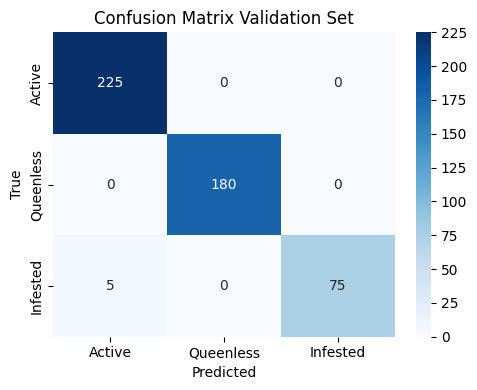

  ROC-AUC: {'Active': 0.9964273504273504, 'Queenless': 1.0, 'Infested': 0.9905864197530864}
  Macro ROC-AUC: 0.9957
  PR-AUC: {'Active': 0.9954696912599551, 'Queenless': 0.9999999999999999, 'Infested': 0.9735584360938982}
  Macro PR-AUC: 0.9897
  Accuracy: 0.9897

=== Test Set ===
              precision    recall  f1-score   support

      Active       0.96      0.99      0.97       220
   Queenless       1.00      1.00      1.00       190
    Infested       0.97      0.88      0.92        80

    accuracy                           0.98       490
   macro avg       0.98      0.96      0.96       490
weighted avg       0.98      0.98      0.98       490



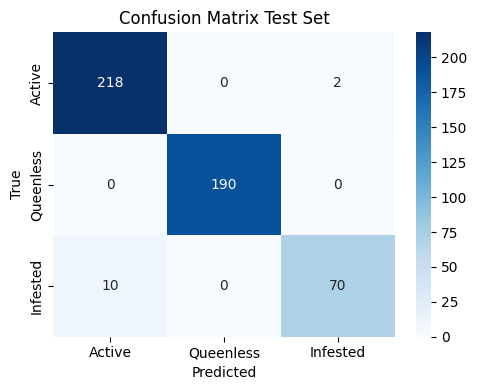

  ROC-AUC: {'Active': 0.9982154882154883, 'Queenless': 1.0, 'Infested': 0.9968292682926829}
  Macro ROC-AUC: 0.9983
  PR-AUC: {'Active': 0.9975938146072837, 'Queenless': 1.0, 'Infested': 0.9881061273651136}
  Macro PR-AUC: 0.9952
  Accuracy: 0.9755


In [16]:
# Load the best EMA model for evaluation
model_eval = timm.create_model(MODEL_NAME, pretrained=False, num_classes=N_CLASSES)
if hasattr(model_eval, 'classifier'):
    in_features = model_eval.classifier.in_features
    model_eval.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.Hardswish(),
        nn.Dropout(0.2),
        nn.Linear(512, N_CLASSES)
    )
model_eval.load_state_dict(
    torch.load('models/best_mobilenetv3_large.pth',
               map_location=DEVICE, weights_only=True))
model_eval = model_eval.to(DEVICE).eval()

val_preds, val_labels, val_probs, thresholds = evaluate_full(
    model_eval, val_loader, DEVICE, class_names,
    thresholds=None, split_name="Validation Set", return_probs=True)

test_preds, test_labels, test_probs, _ = evaluate_full(
    model_eval, test_loader, DEVICE, class_names,
    thresholds=thresholds, split_name="Test Set", return_probs=True)

Loaded EMA model: models/best_mobilenetv3_large_ema.pth


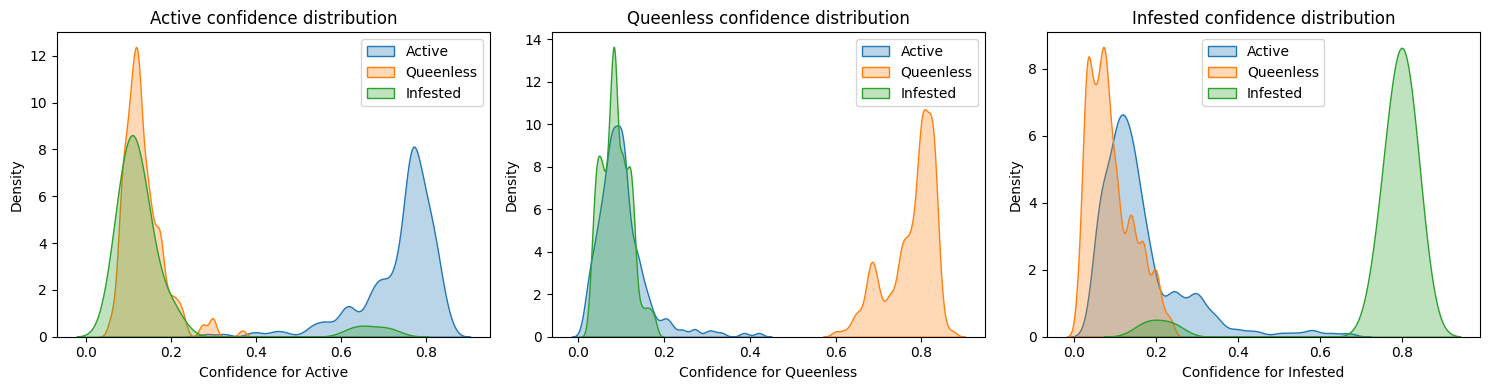

In [17]:
def plot_confidence_density_from_model(model, loader, device, class_names, temperature=1.2):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            probs = F.softmax(model(images) / temperature, dim=1)
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())
    probs = torch.cat(all_probs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, name in enumerate(class_names):
        ax = axes[i]
        for c_idx, c_name in enumerate(class_names):
            mask = labels == c_idx
            if mask.any():
                sns.kdeplot(probs[mask, i], ax=ax, label=c_name, fill=True, alpha=0.3, bw_adjust=0.5)
        ax.set_xlabel(f'Confidence for {name}')
        ax.set_ylabel('Density')
        ax.set_title(f'{name} confidence distribution')
        ax.legend()
    plt.tight_layout()
    plt.show()

# Load EMA model and plot confidence density
model_ema = timm.create_model(MODEL_NAME, pretrained=False, num_classes=N_CLASSES)
if hasattr(model_ema, 'classifier'):
    in_features = model_ema.classifier.in_features
    model_ema.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.Hardswish(),
        nn.Dropout(0.2),
        nn.Linear(512, N_CLASSES)
    )
model_ema.load_state_dict(
    torch.load('models/best_mobilenetv3_large.pth',
               map_location=DEVICE, weights_only=True))
model_ema = model_ema.to(DEVICE).eval()
print(f'Loaded EMA model: models/best_mobilenetv3_large_ema.pth')

plot_confidence_density_from_model(model_ema, val_loader, DEVICE, class_names)

In [ ]:
from pathlib import Path

QL_THR = 0.596
CONTEXT_WINDOW = 1
def predict_df_chunks(model, chunks_df, device):

    model.eval()
    rows = []
    for _, row in tqdm(chunks_df.iterrows(), total=len(chunks_df), desc="Predicting"):
        mel_t = row['mel_tensor']
        if isinstance(mel_t, np.ndarray):
            mel_t = torch.from_numpy(mel_t)
        x = mel_t.unsqueeze(0).to(device)
        with torch.no_grad():
            probs = F.softmax(model(x), dim=1).squeeze(0).cpu().numpy()
        pred = np.argmax(probs)
        rows.append({
            'File_Path': row['File_Path'],
            'Filename': row['Filename'],
            'chunk_id': row['chunk_id'],
            'true_class': row['Class'],
            'pred_class': class_names[pred],
            'conf': probs[pred],
            'prob_ql': probs[1],
            'Hive': row.get('Hive', 'Unknown'),
            'Dataset': row.get('Dataset', 'Unknown'),
            'mel_tensor': row['mel_tensor'],
        })
    return pd.DataFrame(rows)

def expand_neighbors(selected, pool, window=CONTEXT_WINDOW):
    pieces = []
    for _, row in selected.iterrows():
        mask = ((pool['File_Path'] == row['File_Path'])
                & (pool['chunk_id'].between(row['chunk_id'] - window,
                                             row['chunk_id'] + window)))
        nb = pool[mask].copy()
        if len(nb) == 0:
            continue
        nb['sel_chunk_id'] = row['chunk_id']
        nb['sel_conf'] = row['conf']
        nb['sel_pred_class'] = row['pred_class']
        pieces.append(nb)
    if not pieces:
        return pd.DataFrame()
    return pd.concat(pieces, ignore_index=True).drop_duplicates(
        subset=['File_Path', 'chunk_id'])

model_clf = timm.create_model(MODEL_NAME, pretrained=False, num_classes=N_CLASSES)
if hasattr(model_clf, 'classifier'):
    in_features = model_clf.classifier.in_features
    model_clf.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_features, 512), nn.Hardswish(),
        nn.Dropout(0.2), nn.Linear(512, N_CLASSES),
    )
model_clf.load_state_dict(
    torch.load('models/rpi.pth',
               map_location=DEVICE, weights_only=True))
model_clf = model_clf.to(DEVICE).eval()

all_eval = pd.concat([val_chunks, test_chunks], ignore_index=True)
preds = predict_df_chunks(model_clf, all_eval, DEVICE)

ql_mask = (preds['pred_class'] == 'Queenless') & (preds['prob_ql'] >= QL_THR)
ql_chunks = preds[ql_mask].copy()

ql_frdr = ql_chunks[ql_chunks['Dataset'] == 'FRDR']
ql_zen = ql_chunks[ql_chunks['Dataset'] == 'ZENODO']
n_per = min(len(ql_frdr), len(ql_zen))
ql_core = pd.concat([ql_frdr.head(n_per), ql_zen.head(n_per)], ignore_index=True)
ql_expanded = expand_neighbors(ql_core, all_eval)

inf_chunks = preds[preds['true_class'] == 'Infested'].copy()
inf_core_list = []
for hive, grp in inf_chunks.groupby('Hive'):
    inf_core_list.append(grp.head(10))
inf_core = pd.concat(inf_core_list, ignore_index=True) if inf_core_list else pd.DataFrame()
inf_expanded = expand_neighbors(inf_core, all_eval) if not inf_core.empty else pd.DataFrame()

wrong_chunks = preds[preds['pred_class'] != preds['true_class']].copy()
wrong_expanded = expand_neighbors(wrong_chunks, all_eval)

def save_chunks_wav(df, subdir, tag):
    records = []
    for fp, grp in df.groupby('File_Path', sort=False):
        try:
            y_full, fs = torchaudio.load(fp)
            if fs != SR:
                resampler = T.Resample(fs, SR).to(DEVICE)
                y_full = resampler(y_full.to(DEVICE))
            else:
                y_full = y_full.to(DEVICE)
            if y_full.shape[0] > 1:
                y_full = torch.mean(y_full, dim=0, keepdim=True)
        except Exception as e:
            print(f'  SKIP {fp}: {e}')
            continue
        for _, row in grp.iterrows():
            ci = row['chunk_id']
            y_chunk = y_full[:, ci*CHUNK_LEN:(ci+1)*CHUNK_LEN]
            if y_chunk.shape[1] < CHUNK_LEN:
                y_chunk = F.pad(y_chunk, (0, CHUNK_LEN - y_chunk.shape[1]))
            y_np = y_chunk.cpu().numpy()
            y_filt = signal.sosfiltfilt(HIGH_PASS, y_np).copy()
            stem = Path(row['Filename']).stem
            cls = row['Class']
            hive = row.get('Hive', 'Unknown')
            ds = row.get('Dataset', 'Unknown')
            wav_name = f"{tag}_{cls}_{ds}_h{hive}_{stem}_ch{ci:04d}.wav"
            fname = out_dir / subdir / wav_name
            torchaudio.save(str(fname), torch.from_numpy(y_filt).float(), SR)
            records.append({
                'wav_file': str(fname.relative_to(out_dir)),
                'tag': tag,
                'Class': cls,
                'Dataset': ds,
                'Hive': hive,
                'source_file': fp,
                'chunk_id': ci,
                'sel_chunk_id': row.get('sel_chunk_id'),
                'sel_conf': row.get('sel_conf'),
                'sel_pred_class': row.get('sel_pred_class'),
            })
    return pd.DataFrame(records)

out_dir = Path('high_conf_wav')
for sub in ['queenless', 'infested', 'misclassified']:
    (out_dir / sub).mkdir(parents=True, exist_ok=True)

meta_ql = save_chunks_wav(ql_expanded, 'queenless', 'ql')
meta_inf = save_chunks_wav(inf_expanded, 'infested', 'inf')
meta_wrong = save_chunks_wav(wrong_expanded, 'misclassified', 'wrong')

meta_all = pd.concat([meta_ql, meta_inf, meta_wrong], ignore_index=True)
meta_all.to_csv(out_dir / 'manifest.csv', index=False)

n_ql = len(meta_ql)
n_inf = len(meta_inf)
n_wrong = len(meta_wrong)
n_ql_core = len(ql_core)
n_ql_frdr = len(ql_frdr.head(n_per))
n_ql_zen = len(ql_zen.head(n_per))
n_inf_hives = inf_chunks['Hive'].nunique()
print(f"Queenless high-conf: {n_ql} chunks ({n_ql_core} core) [{n_ql_frdr} FRDR + {n_ql_zen} Zenodo]")
print(f"Infested: {n_inf} chunks from {n_inf_hives} hives")
print(f"Misclassified: {n_wrong} chunks")
print(f"\nSaved to {out_dir}/{{queenless, infested, misclassified}}/")
print(f"Manifest: {out_dir / 'manifest.csv'}")

Predicting: 100%|██████████| 975/975 [00:07<00:00, 134.38it/s]


Queenless high-conf: 160 chunks (160 core) [80 FRDR + 80 Zenodo]
Infested: 65 chunks from 7 hives
Misclassified: 14 chunks

Saved to high_conf_wav/{queenless, infested, misclassified}/
Manifest: high_conf_wav\manifest.csv


OK: best2_convnext_tiny (custom_head=True)
OK: best2_efficientnet_b0 (custom_head=True)
OK: best2_efficientnet_b1 (custom_head=True)
OK: best2_mobilenetv3_large_100 (custom_head=True)
OK: best2_mobilenetv3_small_100 (custom_head=True)
OK: best2_mobilenetv4_conv_small (custom_head=True)
OK: best2_regnety_002 (custom_head=True)
OK: best2_regnety_004 (custom_head=True)
OK: best2_resnet18 (custom_head=True)
OK: best2_vgg11_bn (custom_head=True)
OK: best2_vit_tiny_patch16_224 (custom_head=True)

COMPARISON TABLE (sorted by Test F1)
+------------------------+----------+-----------+----------+---------------+--------------+------------+-----------+----------------+---------------+------------+
|         Model          |  Params  |  Val Acc  |  Val F1  |  Val ROC-AUC  |  Val PR-AUC  |  Test Acc  |  Test F1  |  Test ROC-AUC  |  Test PR-AUC  |  Infer/ms  |
+========================+==========+===========+==========+===============+==============+============+===========+================+========

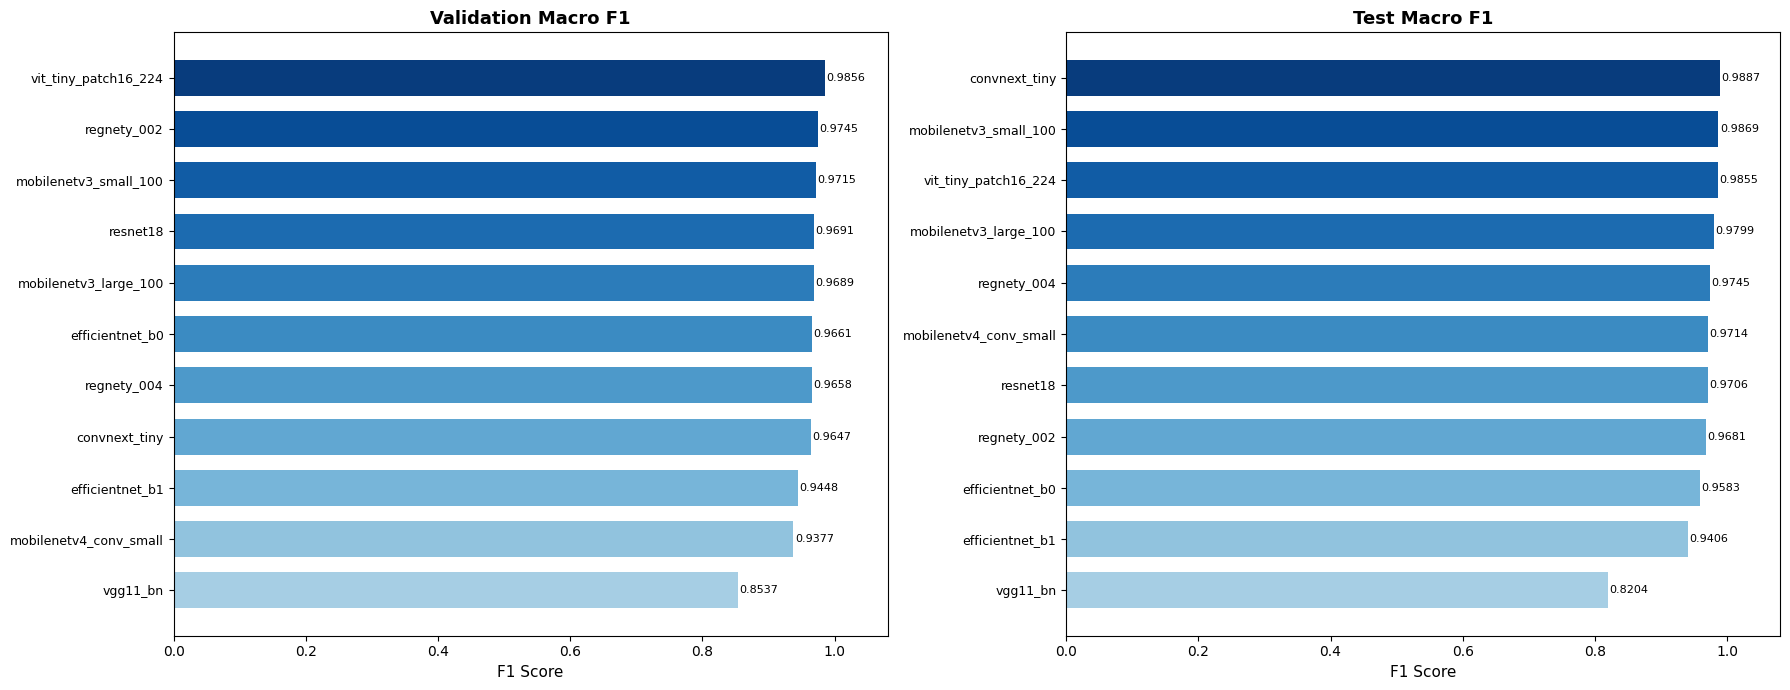

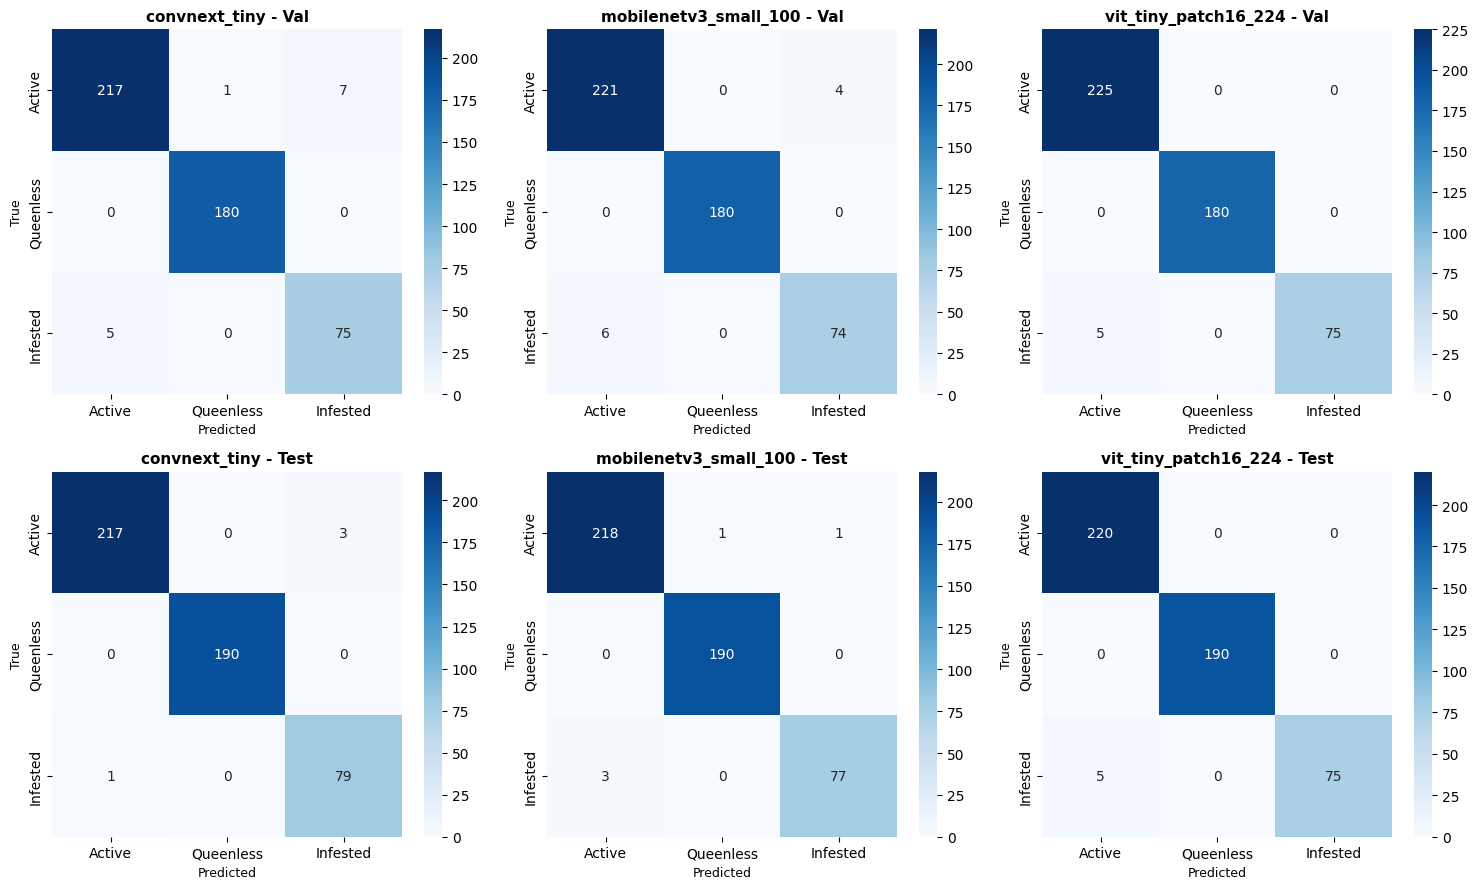

In [ ]:
MODEL_MAP = {
    'best2_convnext_tiny': 'convnext_tiny',
    'best2_efficientnet_b0': 'efficientnet_b0',
    'best2_efficientnet_b1': 'efficientnet_b1',
    'best2_mobilenetv3_large_100': 'mobilenetv3_large_100',
    'best2_mobilenetv3_small_100': 'mobilenetv3_small_100',
    'best2_mobilenetv4_conv_small': 'mobilenetv4_conv_small',
    'best2_regnety_002': 'regnety_002',
    'best2_regnety_004': 'regnety_004',
    'best2_resnet18': 'resnet18',
    'best2_vgg11_bn': 'vgg11_bn',
    'best2_vit_tiny_patch16_224': 'vit_tiny_patch16_224',
}

def _build_model(timm_name, custom_head):
    model = timm.create_model(timm_name, pretrained=False, num_classes=N_CLASSES)
    if custom_head:
        for attr in ('classifier', 'head', 'fc'):
            m = getattr(model, attr, None)
            if m is None:
                continue
            in_f = None
            if hasattr(m, 'in_features'):
                in_f = m.in_features
            elif isinstance(m, nn.Sequential):
                for layer in m:
                    if isinstance(layer, nn.Linear):
                        in_f = layer.in_features
                        break
            if in_f is not None:
                old_head = getattr(model, attr)
                setattr(model, attr, nn.Identity())
                model.eval()
                with torch.no_grad():
                    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
                    feat = model(dummy)
                setattr(model, attr, old_head)
                head_layers = []
                if feat.dim() == 4:
                    head_layers += [nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten()]
                head_layers += [
                    nn.Dropout(0.3), nn.Linear(in_f, 512), nn.Hardswish(),
                    nn.Dropout(0.2), nn.Linear(512, N_CLASSES)]
                setattr(model, attr, nn.Sequential(*head_layers))
                break
    return model.to(DEVICE).eval()

def _remap_state(state, attr, model):

    pref = f'{attr}.'
    new_state = {}
    head = getattr(model, attr)
    lin_idx = [i for i, m in enumerate(head) if isinstance(m, nn.Linear)]
    for k, v in state.items():
        if not k.startswith(pref):
            new_state[k] = v
            continue
        rest = k[len(pref):]
        shape = tuple(v.shape)
        is_w = '.weight' in rest
        is_b = '.bias' in rest
        if is_w and len(shape) == 2 and shape[0] == 512 and shape[1] != N_CLASSES:
            new_state[f'{pref}{lin_idx[0]}.{rest.split(chr(46), 1)[1]}'] = v
        elif is_w and len(shape) == 2 and shape[1] == 512 and shape[0] != 512:
            new_state[f'{pref}{lin_idx[1]}.{rest.split(chr(46), 1)[1]}'] = v
        elif is_b and v.numel() == 512 and len(shape) == 1:
            new_state[f'{pref}{lin_idx[0]}.{rest.split(chr(46), 1)[1]}'] = v
        elif is_b and v.numel() == N_CLASSES and len(shape) == 1:
            new_state[f'{pref}{lin_idx[1]}.{rest.split(chr(46), 1)[1]}'] = v
        else:
            new_state[k] = v
    return new_state

def _try_load(stem, timm_name, custom_head):
    model = _build_model(timm_name, custom_head)
    state = torch.load(f'models/{stem}.pth', map_location=DEVICE, weights_only=True)
    if custom_head:
        for attr in ('classifier', 'head', 'fc'):
            if any(k.startswith(f'{attr}.') for k in state):
                state = _remap_state(state, attr, model)
                break
    model.load_state_dict(state, strict=True)
    return model

def load_model(stem, timm_name):
    for custom in [True, False]:
        try:
            return _try_load(stem, timm_name, custom), custom
        except Exception as e:
            print(f'  [custom={custom}] {type(e).__name__}: {e}')  # <-- เพิ่ม
            continue

    raise RuntimeError(f'Cannot load {stem}')

def _eval_model(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            probs = F.softmax(model(images) / 1.2, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    preds = probs.argmax(1)
    acc = (preds == labels).mean()
    labels_bin = np.eye(N_CLASSES)[labels]
    roc = np.mean([roc_auc_score(labels_bin[:, i], probs[:, i]) for i in range(N_CLASSES)])
    pr = np.mean([average_precision_score(labels_bin[:, i], probs[:, i]) for i in range(N_CLASSES)])
    report = classification_report(labels, preds, target_names=class_names, output_dict=True, zero_division=0)
    f1 = report['macro avg']['f1-score']
    cm = confusion_matrix(labels, preds)
    return acc, f1, roc, pr, cm, probs, labels

rows = []
details = {}
for stem, timm_name in MODEL_MAP.items():
    try:
        model, custom = load_model(stem, timm_name)
        n_params = sum(p.numel() for p in model.parameters())
        t0 = time.time()
        val_acc, val_f1, val_roc, val_pr, val_cm, val_probs, val_labels = _eval_model(model, val_loader, DEVICE)
        test_acc, test_f1, test_roc, test_pr, test_cm, test_probs, test_labels = _eval_model(model, test_loader, DEVICE)
        elapsed = time.time() - t0
        n_samples = len(val_loader.dataset) + len(test_loader.dataset)
        infer_ms = elapsed / n_samples * 1000 if n_samples else 0
        rows.append({
            'Model': stem.replace('best2_', ''),
            'Params': f'{n_params/1e6:.1f}M',
            'Val Acc': f'{val_acc:.4f}',
            'Val F1': f'{val_f1:.4f}',
            'Val ROC-AUC': f'{val_roc:.4f}',
            'Val PR-AUC': f'{val_pr:.4f}',
            'Test Acc': f'{test_acc:.4f}',
            'Test F1': f'{test_f1:.4f}',
            'Test ROC-AUC': f'{test_roc:.4f}',
            'Test PR-AUC': f'{test_pr:.4f}',
            'Infer/ms': f'{infer_ms:.2f}',
            'custom_head': custom,
        })
        details[stem] = {'val_cm': val_cm, 'test_cm': test_cm}
        print(f'OK: {stem} (custom_head={custom})')
    except Exception as e:
        print(f'FAIL: {stem} - {e}')

df_results = pd.DataFrame(rows)

print('\n' + '='*130)
print('COMPARISON TABLE (sorted by Test F1)')
print('='*130)
tbl = df_results.drop(columns=['custom_head']).sort_values('Test F1', ascending=False)
print(tabulate(tbl, headers='keys', tablefmt='grid', showindex=False, numalign='center', stralign='center'))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, metric, title in zip(axes, ['Val F1', 'Test F1'], ['Validation Macro F1', 'Test Macro F1']):
    df_sorted = df_results.sort_values(metric, ascending=True)
    vals = df_sorted[metric].astype(float)
    colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(df_sorted)))
    bars = ax.barh(range(len(df_sorted)), vals, color=colors, height=0.7)
    ax.set_yticks(range(len(df_sorted)))
    ax.set_yticklabels(df_sorted['Model'].values, fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=8)
    ax.set_xlabel('F1 Score', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1.08)
    ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

top3 = df_results.sort_values('Test F1', ascending=False).head(3)['Model'].values
top3_stems = [f'best2_{n}' for n in top3]
n_top = len(top3_stems)
fig, axes = plt.subplots(2, n_top, figsize=(5*n_top, 9))
for col, stem in enumerate(top3_stems):
    d = details[stem]
    for row, cm_key, split in [(0, 'val_cm', 'Val'), (1, 'test_cm', 'Test')]:
        sns.heatmap(d[cm_key], annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=axes[row][col])
        axes[row][col].set_title(f'{stem.replace("best2_","")} - {split}', fontsize=11, fontweight='bold')
        axes[row][col].set_xlabel('Predicted', fontsize=9)
        axes[row][col].set_ylabel('True', fontsize=9)
plt.tight_layout()
plt.show()